In [267]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [268]:
df = pd.read_json("/Users/chandra.saripaka/Downloads/part-00000-a8512aa2-361d-4284-a2fd-caa5c5d62c4c-c000.json", lines=True, encoding='utf-8')

In [269]:
import yake 

data1=df[df['level'].isin(['ERROR'])]
data1['cm'] = data1['class'].str.cat(data1['message'],sep=" ")

data1=data1.drop(columns=['date', 'time', 'filename', 'message', 'class', 'level'])
data1=data1.drop_duplicates()

language = "en"
max_ngram_size = 3
deduplication_thresold = 0.9
deduplication_algo = 'seqm'
windowSize = 1
numOfKeywords = 10

custom_kw_extractor = yake.KeywordExtractor(lan=language, n=max_ngram_size, dedupLim=deduplication_thresold, dedupFunc=deduplication_algo, windowsSize=windowSize, top=numOfKeywords, features=None)

def extract_keywords(text):
        
    post_keywords = custom_kw_extractor.extract_keywords(text)

    sentence_output = ""
    for word, number in post_keywords:
        sentence_output += word + " "

    return sentence_output
    
data1['summary']=data1['cm'].apply(extract_keywords)
    
#data=data1.cm.values.tolist()
#data1=data1.drop(columns=['date', 'time', 'filename', 'message', 'class', 'level'])
#data1=data1.drop_duplicates()
print(data1)

                                                                                                                                                                                                             cm  \
1                                                                                                                                                             CoarseGrainedExecutorBackend RECEIVED SIGNAL TERM   
230     TransportRequestHandler Error sending result RpcResponse{requestId=7779991441153733603, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=81 cap=156]}} to /10.130.161.12:29122; closing c...   
231     TransportRequestHandler Error sending result RpcResponse{requestId=7218885748387219629, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=81 cap=156]}} to /10.130.165.106:40566; closing ...   
232     TransportRequestHandler Error sending result RpcResponse{requestId=9142049755062446761, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=

In [320]:
data1['cm'][:100]

1                                                                                                                                                              CoarseGrainedExecutorBackend RECEIVED SIGNAL TERM
230      TransportRequestHandler Error sending result RpcResponse{requestId=7779991441153733603, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=81 cap=156]}} to /10.130.161.12:29122; closing c...
231      TransportRequestHandler Error sending result RpcResponse{requestId=7218885748387219629, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=81 cap=156]}} to /10.130.165.106:40566; closing ...
232      TransportRequestHandler Error sending result RpcResponse{requestId=9142049755062446761, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=81 cap=156]}} to /10.130.73.194:22526; closing c...
287      TransportRequestHandler Error sending result RpcResponse{requestId=5073223262981081518, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=81 cap=

In [321]:
import re
import spacy
nlp = spacy.load('en')

def spacy_process(text):
    doc = nlp(text)
    
#Tokenization and lemmatization are done with the spacy nlp pipeline commands
    lemma_list = []
    for token in doc:
        lemma_list.append(token.lemma_)
    #print("Tokenize+Lemmatize:")
    #print(lemma_list)
    
    #Filter the stopword
    filtered_sentence =[] 
    for word in lemma_list:
        lexeme = nlp.vocab[word]
        if lexeme.is_stop == False:
            filtered_sentence.append(word) 
    
    #Remove punctuation
    punctuations="?:!.,;"
    for word in filtered_sentence:
        if word in punctuations:
            filtered_sentence.remove(word)
    #print(" ")
    #print("Remove stopword & punctuation: ")
    #print(filtered_sentence)
    return " ".join(filtered_sentence)

#Removes non-alphabetic characters:
def text_strip(column):
    for row in column:
        
        row = spacy_process(str(row))
        row=re.sub("(__+)", ' ', str(row)).lower()   #remove _ if it occors more than one time consecutively
        row=re.sub("(--+)", ' ', str(row)).lower()   #remove - if it occors more than one time consecutively
        row=re.sub("(~~+)", ' ', str(row)).lower()   #remove ~ if it occors more than one time consecutively
        row=re.sub("(\+\++)", ' ', str(row)).lower()   #remove + if it occors more than one time consecutively
        row=re.sub("(\.\.+)", ' ', str(row)).lower()   #remove . if it occors more than one time consecutively
        
        row=re.sub("(\s+.\s+)", ' ', str(row)).lower() #remove any single charecters hanging between 2 spaces

        row = re.sub("(\s+)",' ',str(row)).lower() #remove multiple spaces
        
        #Should always be last
        row=re.sub("(\s+.\s+)", ' ', str(row)).lower() #remove any single charecters hanging between 2 spaces
        
        yield row

In [322]:
brief_cleaning1 = text_strip(data1['cm'])
brief_cleaning2 = text_strip(data1['summary'])

In [323]:
from time import time
import spacy
nlp = spacy.load('en', disable=['ner', 'parser']) # disabling Named Entity Recognition for speed

#Taking advantage of spaCy .pipe() method to speed-up the cleaning process:
#If data loss seems to be happening(i.e len(text) = 50 instead of 75 etc etc) in this cell , decrease the batch_size parametre 

t = time()

#Batch the data points into 5000 and run on all cores for faster preprocessing
text = [str(doc) for doc in brief_cleaning1]

#Takes 7-8 mins
print('Time to clean up everything: {} mins'.format(round((time() - t) / 60, 2)))
#print(text)

Time to clean up everything: 0.33 mins


**Seq2Seq LSTM Modelling**
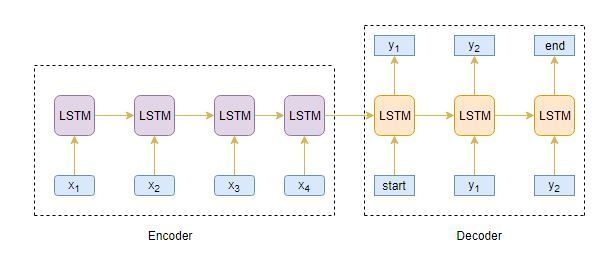

> **Perform Data Cleansing**

In [324]:
#Taking advantage of spaCy .pipe() method to speed-up the cleaning process:


t = time()

#Batch the data points into 5000 and run on all cores for faster preprocessing
summary = ['_START_ '+ str(doc) + ' _END_' for doc in brief_cleaning2]

#Takes 7-8 mins
print('Time to clean up everything: {} mins'.format(round((time() - t) / 60, 2)))
#print(summary)

Time to clean up everything: 0.24 mins


In [325]:
text[0]
len(text)

8621

In [326]:
summary[0]
len(summary)

8621

In [327]:
#data1['cleaned_text'] = pd.Series(text)
#data1['cleaned_summary'] = pd.Series(summary)
data1['cleaned_text'] = text
data1['cleaned_summary'] = summary

In [328]:
text_count = []
summary_count = []

In [329]:
for sent in data1['cleaned_text']:
    text_count.append(len(str(sent).split()))
for sent in data1['cleaned_summary']:
    summary_count.append(len(str(sent).split()))

In [330]:
graph_df= pd.DataFrame()
graph_df['text']=text_count
graph_df['summary']=summary_count

In [ ]:
from matplotlib import pyplot as plt

graph_df.hist(bins = 5)
plt.show()

In [333]:
#Check how much % of summary have 0-15 words
cnt=0
for i in data1['cleaned_summary']:
    if(str(i) != 'nan' and len(i.split())<=15):
        cnt=cnt+1
print(cnt/len(data1['cleaned_summary']))

0.0197192901055562


In [334]:
#Check how much % of text have 0-70 words
cnt=0
for i in data1['cleaned_text']:
    if(str(i) != 'nan' and len(i.split())<=100):
        cnt=cnt+1
print(cnt/len(data1['cleaned_text']))

1.0


In [362]:
#Model to summarize the text between 0-15 words for Summary and 0-100 words for Text
max_text_len=200
max_summary_len=50

In [363]:
#Select the Summaries and Text between max len defined above

cleaned_text =np.array(data1['cleaned_text'])
cleaned_summary=np.array(data1['cleaned_summary'])

short_text=[]
short_summary=[]

for i in range(len(cleaned_text)):
    if(len(cleaned_summary[i].split())<=max_summary_len and len(cleaned_text[i].split())<=max_text_len):
        short_text.append(cleaned_text[i])
        short_summary.append(cleaned_summary[i])
        
data2=pd.DataFrame({'text':short_text,'summary':short_summary})

In [364]:
data2.head(2)

AttributeError: 'NoneType' object has no attribute 'items'

                                                                                                                                                                                               text  \
0                                                                                                                                                  coarsegrainedexecutorbackend receive signal term   
1  transportrequesthandler error send result rpcresponse{requestid=7779991441153733603 body niomanagedbuffer{buf java.nio heapbytebuffer[pos=0 lim=81 cap=156 /10.130.161.12:29122 close connection   

                                                                                                                                                                                           summary  
0  _START_ receive signal term coarsegrainedexecutorbackend receive signal signal term receive signal coarsegrainedexecutorbackend received term receive signal coarsegrainedexecutorbackend _END_  
1       

In [365]:
#Add sostok and eostok at 
data2['summary'] = data2['summary'].apply(lambda x : 'sostok '+ x + ' eostok')


In [366]:
data2

AttributeError: 'NoneType' object has no attribute 'items'

                                                                                                                                                                                                   text  \
0                                                                                                                                                      coarsegrainedexecutorbackend receive signal term   
1      transportrequesthandler error send result rpcresponse{requestid=7779991441153733603 body niomanagedbuffer{buf java.nio heapbytebuffer[pos=0 lim=81 cap=156 /10.130.161.12:29122 close connection   
2     transportrequesthandler error send result rpcresponse{requestid=7218885748387219629 body niomanagedbuffer{buf java.nio heapbytebuffer[pos=0 lim=81 cap=156 /10.130.165.106:40566 close connection   
3      transportrequesthandler error send result rpcresponse{requestid=9142049755062446761 body niomanagedbuffer{buf java.nio heapbytebuffer[pos=0 lim=81 cap=156 /10.130.73.194:22526 close

**SEQ2SEQ MODEL BUILDING **

Split the data to TRAIN and VALIDATION sets

In [367]:
from sklearn.model_selection import train_test_split
x_tr,x_val,y_tr,y_val=train_test_split(np.array(data2['text']),np.array(data2['summary']),test_size=0.1,random_state=0,shuffle=True)

In [368]:
#Lets tokenize the text to get the vocab count , you can use Spacy here also

from keras.preprocessing.text import Tokenizer 
from keras.preprocessing.sequence import pad_sequences

#prepare a tokenizer for reviews on training data
x_tokenizer = Tokenizer() 
x_tokenizer.fit_on_texts(list(x_tr))

**RARE WORD ANALYSIS FOR X i.e 'text'**
* tot_cnt gives the size of vocabulary (which means every unique words in the text)

* cnt gives me the no. of rare words whose count falls below threshold

* tot_cnt - cnt gives me the top most common words

In [369]:
thresh=4

cnt=0
tot_cnt=0
freq=0
tot_freq=0

for key,value in x_tokenizer.word_counts.items():
    tot_cnt=tot_cnt+1
    tot_freq=tot_freq+value
    if(value<thresh):
        cnt=cnt+1
        freq=freq+value
    
print("% of rare words in vocabulary:",(cnt/tot_cnt)*100)
print("Total Coverage of rare words:",(freq/tot_freq)*100)

% of rare words in vocabulary: 89.2197215167703
Total Coverage of rare words: 17.75212617160496


In [370]:

#prepare a tokenizer for reviews on training data
x_tokenizer = Tokenizer(num_words=tot_cnt-cnt) 
x_tokenizer.fit_on_texts(list(x_tr))

#convert text sequences into integer sequences (i.e one-hot encodeing all the words)
x_tr_seq    =   x_tokenizer.texts_to_sequences(x_tr) 
x_val_seq   =   x_tokenizer.texts_to_sequences(x_val)

#padding zero upto maximum length
x_tr    =   pad_sequences(x_tr_seq,  maxlen=max_text_len, padding='post')
x_val   =   pad_sequences(x_val_seq, maxlen=max_text_len, padding='post')

#size of vocabulary ( +1 for padding token)
x_voc   =  x_tokenizer.num_words + 1

print("Size of vocabulary in X = {}".format(x_voc))

Size of vocabulary in X = 2463


**RARE WORD ANALYSIS FOR Y i.e 'summary'**
* tot_cnt gives the size of vocabulary (which means every unique words in the text)

* cnt gives me the no. of rare words whose count falls below threshold

* tot_cnt - cnt gives me the top most common words

In [371]:
#prepare a tokenizer for reviews on training data
y_tokenizer = Tokenizer()   
y_tokenizer.fit_on_texts(list(y_tr))

In [372]:
thresh=6

cnt=0
tot_cnt=0
freq=0
tot_freq=0

for key,value in y_tokenizer.word_counts.items():
    tot_cnt=tot_cnt+1
    tot_freq=tot_freq+value
    if(value<thresh):
        cnt=cnt+1
        freq=freq+value
    
print("% of rare words in vocabulary:",(cnt/tot_cnt)*100)
print("Total Coverage of rare words:",(freq/tot_freq)*100)

% of rare words in vocabulary: 48.06866952789699
Total Coverage of rare words: 0.15216809819597585


In [373]:
#prepare a tokenizer for reviews on training data
y_tokenizer = Tokenizer(num_words=tot_cnt-cnt) 
y_tokenizer.fit_on_texts(list(y_tr))

#convert text sequences into integer sequences (i.e one hot encode the text in Y)
y_tr_seq    =   y_tokenizer.texts_to_sequences(y_tr) 
y_val_seq   =   y_tokenizer.texts_to_sequences(y_val) 

#padding zero upto maximum length
y_tr    =   pad_sequences(y_tr_seq, maxlen=max_summary_len, padding='post')
y_val   =   pad_sequences(y_val_seq, maxlen=max_summary_len, padding='post')

#size of vocabulary
y_voc  =   y_tokenizer.num_words +1
print("Size of vocabulary in Y = {}".format(y_voc))

Size of vocabulary in Y = 122


We will now remove "Summary" i.e Y (both train and val) which has only _START_ and _END_

In [374]:
ind=[]
for i in range(len(y_tr)):
    cnt=0
    for j in y_tr[i]:
        if j!=0:
            cnt=cnt+1
    if(cnt==2):
        ind.append(i)

y_tr=np.delete(y_tr,ind, axis=0)
x_tr=np.delete(x_tr,ind, axis=0)

In [375]:
ind=[]
for i in range(len(y_val)):
    cnt=0
    for j in y_val[i]:
        if j!=0:
            cnt=cnt+1
    if(cnt==2):
        ind.append(i)

y_val=np.delete(y_val,ind, axis=0)
x_val=np.delete(x_val,ind, axis=0)

In [376]:
from keras import backend as K 
import gensim
from numpy import *
import numpy as np
import pandas as pd 
import re
from bs4 import BeautifulSoup
from keras.preprocessing.text import Tokenizer 
from keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import warnings
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore")

print("Size of vocabulary from the w2v model = {}".format(x_voc))

K.clear_session()

latent_dim = 300
embedding_dim=200

# Encoder
encoder_inputs = Input(shape=(max_text_len,))

#embedding layer
enc_emb =  Embedding(x_voc, embedding_dim,trainable=True)(encoder_inputs)

#encoder lstm 1
encoder_lstm1 = LSTM(latent_dim,return_sequences=True,return_state=True,dropout=0.4,recurrent_dropout=0.4)
encoder_output1, state_h1, state_c1 = encoder_lstm1(enc_emb)

#encoder lstm 2
encoder_lstm2 = LSTM(latent_dim,return_sequences=True,return_state=True,dropout=0.4,recurrent_dropout=0.4)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1)

#encoder lstm 3
encoder_lstm3=LSTM(latent_dim, return_state=True, return_sequences=True,dropout=0.4,recurrent_dropout=0.4)
encoder_outputs, state_h, state_c= encoder_lstm3(encoder_output2)

# Set up the decoder, using `encoder_states` as initial state.
decoder_inputs = Input(shape=(None,))

#embedding layer
dec_emb_layer = Embedding(y_voc, embedding_dim,trainable=True)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True,dropout=0.4,recurrent_dropout=0.2)
decoder_outputs,decoder_fwd_state, decoder_back_state = decoder_lstm(dec_emb,initial_state=[state_h, state_c])

#dense layer
decoder_dense =  TimeDistributed(Dense(y_voc, activation='softmax'))
decoder_outputs = decoder_dense(decoder_outputs)

# Define the model 
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.summary()


Size of vocabulary from the w2v model = 2463
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 200)]        0                                            
__________________________________________________________________________________________________
embedding (Embedding)           (None, 200, 200)     492600      input_1[0][0]                    
__________________________________________________________________________________________________
lstm (LSTM)                     [(None, 200, 300), ( 601200      embedding[0][0]                  
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, None)]       0                                            
_________________________________________________

In [377]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')


In [378]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1,patience=2)


**Start fitting the model with the data**

In [ ]:
history=model.fit([x_tr,y_tr[:,:-1]], y_tr.reshape(y_tr.shape[0],y_tr.shape[1], 1)[:,1:] ,epochs=50,callbacks=[es],batch_size=128, validation_data=([x_val,y_val[:,:-1]], y_val.reshape(y_val.shape[0],y_val.shape[1], 1)[:,1:]))


Train on 7758 samples, validate on 863 samples
Epoch 1/50
7758/7758 [==============================] - 324s 42ms/sample - loss: 1.4517 - val_loss: 0.9002
Epoch 2/50
7758/7758 [==============================] - 308s 40ms/sample - loss: 0.6105 - val_loss: 0.2938
Epoch 3/50
7758/7758 [==============================] - 301s 39ms/sample - loss: 0.1840 - val_loss: 0.1129
Epoch 4/50
7758/7758 [==============================] - 300s 39ms/sample - loss: 0.0920 - val_loss: 0.0732
Epoch 5/50
7758/7758 [==============================] - 301s 39ms/sample - loss: 0.0581 - val_loss: 0.0436
Epoch 6/50
7758/7758 [==============================] - 302s 39ms/sample - loss: 0.0425 - val_loss: 0.0349
Epoch 7/50
7758/7758 [==============================] - 302s 39ms/sample - loss: 0.0403 - val_loss: 0.0300
Epoch 8/50
7758/7758 [==============================] - 302s 39ms/sample - loss: 0.0352 - val_loss: 0.0303
Epoch 9/50
7758/7758 [==============================] - 303s 39ms/sample - loss: 0.0308 - val_los

**Visualize the model learning**

In [ ]:
from matplotlib import pyplot
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

**Next, let’s build the dictionary to convert the index to word for target and source vocabulary:**

In [ ]:
reverse_target_word_index=y_tokenizer.index_word
reverse_source_word_index=x_tokenizer.index_word
target_word_index=y_tokenizer.word_index

In [ ]:
# Encode the input sequence to get the feature vector
encoder_model = Model(inputs=encoder_inputs,outputs=[encoder_outputs, state_h, state_c])

# Decoder setup
# Below tensors will hold the states of the previous time step
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_hidden_state_input = Input(shape=(max_text_len,latent_dim))

# Get the embeddings of the decoder sequence
dec_emb2= dec_emb_layer(decoder_inputs) 
# To predict the next word in the sequence, set the initial states to the states from the previous time step
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])

# A dense softmax layer to generate prob dist. over the target vocabulary
decoder_outputs2 = decoder_dense(decoder_outputs2) 

# Final decoder model
decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input,decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2])

**We are defining a function below which is the implementation of the inference process**

In [ ]:
def decode_sequence(input_seq):
    # Encode the input as state vectors.
    e_out, e_h, e_c = encoder_model.predict(input_seq)
    
    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1,1))
    
    # Populate the first word of target sequence with the start word.
    target_seq[0, 0] = target_word_index['sostok']

    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
      
        output_tokens, h, c = decoder_model.predict([target_seq] + [e_out, e_h, e_c])

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = reverse_target_word_index[sampled_token_index]
        
        if(sampled_token!='eostok'):
            decoded_sentence += ' '+sampled_token

        # Exit condition: either hit max length or find stop word.
        if (sampled_token == 'eostok'  or len(decoded_sentence.split()) >= (max_summary_len-1)):
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        # Update internal states
        e_h, e_c = h, c

    return decoded_sentence

**Let us define the functions to convert an integer sequence to a word sequence for summary as well as the reviews:**


In [ ]:
def seq2summary(input_seq):
    newString=''
    for i in input_seq:
        if((i!=0 and i!=target_word_index['sostok']) and i!=target_word_index['eostok']):
            newString=newString+reverse_target_word_index[i]+' '
    return newString

def seq2text(input_seq):
    newString=''
    for i in input_seq:
        if(i!=0):
            newString=newString+reverse_source_word_index[i]+' '
    return newString

**Run the model over the data to see the results**

In [ ]:
for i in range(0,100):
    print("Review:",seq2text(x_tr[i]))
    print("Original summary:",seq2summary(y_tr[i]))
    print("Predicted summary:",decode_sequence(x_tr[i].reshape(1,max_text_len)))
    print("\n")